# Brownian Motion’s “Counterintuitive Geometry”: Quadratic Variation

## Roadmap
1. Quadratic variation is the **right second-order geometry** for rough paths
2. Brownian motion has **infinite total variation** but **finite quadratic variation**

3. For an Itô process $X=A+M$, the finite-variation part is invisible to quadratic variation
4. Covariation and polarization: $[X,Y]$ is the bilinear second-order object
5. For a continuous martingale, $M_t^2-[M]_t$ is the compensated square
6. Lévy’s characterization and DDS: quadratic variation is the martingale’s **clock**
7. Simulations: pathwise realized QV, drift invariance, stochastic-volatility clock, covariation, and compensated-square diagnostics


The whole point is this:

> Brownian motion is not smooth enough for ordinary calculus, but it is just regular enough to possess a stable **second-order** geometry.


In [1]:
# Setup
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

rng = np.random.default_rng(3)

plt.rcParams.update({
    "figure.figsize": (9, 4.8),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

_fig_counter = 0
def show_caption(text, label=None):
    global _fig_counter
    _fig_counter += 1
    prefix = f"**Figure {_fig_counter}.** "
    if label is not None:
        prefix += f"({label}) "
    display(Markdown(prefix + text))


## 1. Quadratic variation is the “surviving second order”

For a partition $P=\{0=t_0<t_1<\cdots<t_n=t\}$, define the realized quadratic variation

$$QV_P(X;t):=\sum_{i=1}^n (X_{t_i}-X_{t_{i-1}})^2.$$

For Brownian motion $B$, these sums converge (along refining deterministic partitions) to

$$[B]_t=t.$$

This is already a small miracle. If $B$ were smooth, each increment would be $O(\Delta t)$, so each square would be $O((\Delta t)^2)$, and the whole sum would vanish. But Brownian increments are $O(\sqrt{\Delta t})$, so their squares are $O(\Delta t)$, and summing them produces something macroscopic.

That is the hidden geometric rule behind Itô calculus:

$$(dB_t)^2 \sim dt.$$

The correct mental picture is **not**
“Brownian motion is differentiable but noisy,”

but rather

> “Brownian motion is so rough that first-order geometry breaks, yet second-order energy remains stable.”


## 2. Why this is counterintuitive: infinite total variation, finite quadratic variation

The total variation along the same partition is

$$TV_P(B;t):=\sum_i |B_{t_i}-B_{t_{i-1}}|.$$

For Brownian motion this blows up, while the quadratic variation converges to $t$.



So Brownian motion sits in a peculiar class:
* too rough to have finite variation,
* but not so rough that every second-order aggregate explodes.

That mismatch is exactly why Riemann-Stieltjes intuition fails and Itô’s correction term appears.


## 3. Advanced upgrade: for an Itô process, the drift disappears from quadratic variation

Suppose
\[
X_t=X_0+\int_0^t \mu_s\,ds+\int_0^t \sigma_s\,dB_s.
\]

Then the finite-variation drift part contributes **zero** quadratic variation and zero covariation with the martingale part, so
\[
[X]_t=\int_0^t \sigma_s^2\,ds.
\]

This is the big structural upgrade beyond plain Brownian motion:
- quadratic variation does **not** see drift,
- it sees only the accumulated local variance.

In short:
\[
\text{drift} \;\;\text{is first-order},\qquad
\text{noise} \;\;\text{is second-order}.
\]

This is why realized variance estimates volatility, not drift.


## 4. Covariation: the bilinear version

For two processes \(X,Y\),
\[
[X,Y]_t = \lim \sum_i (X_{t_i}-X_{t_{i-1}})(Y_{t_i}-Y_{t_{i-1}}).
\]

A clean identity is the polarization formula:
\[
[X,Y]_t=\frac12\big([X+Y]_t-[X]_t-[Y]_t\big).
\]

For correlated Brownian motions \(B^{(1)},B^{(2)}\) with correlation \(\rho\),
\[
[B^{(1)},B^{(2)}]_t = \rho t.
\]

For Itô processes driven by the same Brownian motion,
\[
dX_t=\mu^X_tdt+\sigma^X_t dB_t,\qquad
dY_t=\mu^Y_tdt+\sigma^Y_t dB_t,
\]
we get
\[
[X,Y]_t=\int_0^t \sigma^X_s \sigma^Y_s\,ds.
\]

So covariation is the pathwise version of instantaneous covariance.


## 5. The compensated square: \(M_t^2-[M]_t\)

For a continuous martingale \(M\), the process
\[
M_t^2-[M]_t
\]
is itself a martingale.

This is not just a cute identity. It says quadratic variation is the **compensator** of the square:
- \(M_t^2\) wants to grow on average;
- subtract exactly \([M]_t\), and the predictable growth disappears.

This turns \([M]_t\) into the martingale’s internal variance budget.

For Brownian motion, this reduces to the familiar fact:
\[
B_t^2-t
\]
is a martingale.


## 6. The deepest payoff: quadratic variation is the clock

Two major theorems make this precise.

### Lévy characterization
A continuous local martingale \(M\) is Brownian motion **iff**
\[
[M]_t=t.
\]

So Brownian motion is exactly “continuous martingale with unit-speed quadratic variation.”

### Dambis–Dubins–Schwarz (DDS), preview
A continuous martingale can be represented as Brownian motion run on its own clock:
\[
M_t = W_{[M]_t}
\]
for a suitable Brownian motion \(W\).

This is wildly important. It says quadratic variation is not just a diagnostic —
it is the time-change that turns a general continuous martingale into Brownian motion.


## 7. Simulation utilities

We simulate on a fine dyadic grid and reuse the same path across coarser dyadic partitions.
That makes “mesh \(\to 0\)” visible without resimulating everything.


In [2]:
def simulate_brownian_path(T=1.0, J=15, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    N = 2**J
    dt = T / N
    dB = np.sqrt(dt) * rng.standard_normal(N)
    B = np.concatenate([[0.0], np.cumsum(dB)])
    t = np.linspace(0.0, T, N+1)
    return t, B, dB, dt

def realized_qv_from_fine_increments(dX, level):
    # level = k means 2^k coarse intervals
    Nfine = len(dX)
    J = int(np.log2(Nfine))
    block = 2**(J - level)
    coarse_increments = dX.reshape(2**level, block).sum(axis=1)
    return np.sum(coarse_increments**2)

def realized_tv_from_fine_increments(dX, level):
    Nfine = len(dX)
    J = int(np.log2(Nfine))
    block = 2**(J - level)
    coarse_increments = dX.reshape(2**level, block).sum(axis=1)
    return np.sum(np.abs(coarse_increments))

def realized_cov_from_fine_increments(dX, dY, level):
    Nfine = len(dX)
    J = int(np.log2(Nfine))
    block = 2**(J - level)
    DX = dX.reshape(2**level, block).sum(axis=1)
    DY = dY.reshape(2**level, block).sum(axis=1)
    return np.sum(DX * DY)


## 8. Visual experiment A — one Brownian path, and realized QV across meshes

This is the basic sanity check, but we keep it because everything else sits on top of it.


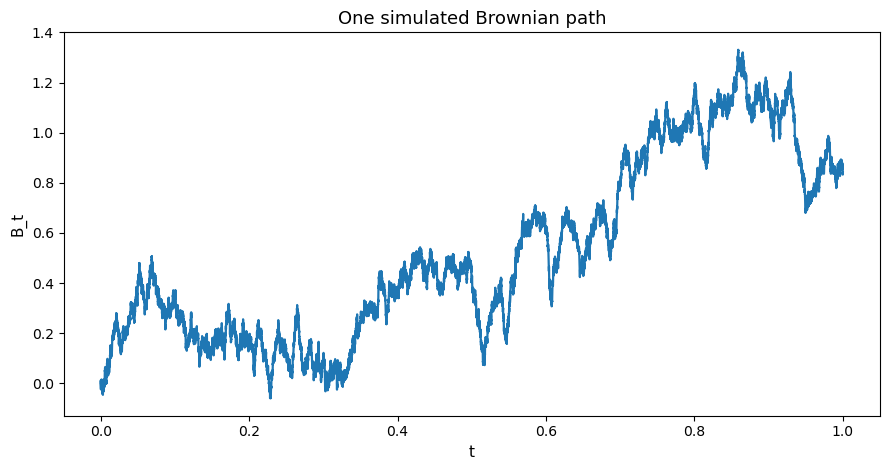

**Figure 1.** A single Brownian path looks continuous but geometrically wild: no tangent, no finite variation, but stable quadratic variation.

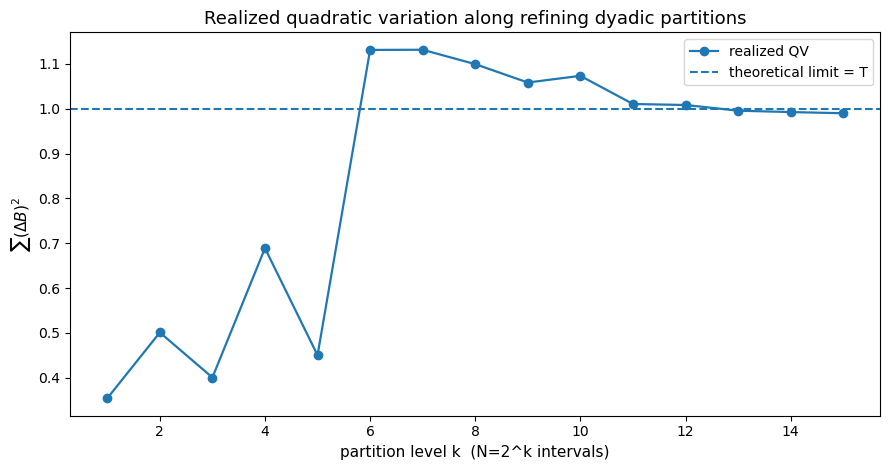

**Figure 2.** The realized quadratic variation stabilizes near T. That is the pathwise shadow of $[B]_T=T$.

In [3]:
T = 1.0
J = 15
t, B, dB, dt = simulate_brownian_path(T=T, J=J, rng=rng)

levels = np.arange(1, J+1)
QV = np.array([realized_qv_from_fine_increments(dB, k) for k in levels])

plt.figure()
plt.plot(t, B, linewidth=1.6)
plt.title("One simulated Brownian path")
plt.xlabel("t")
plt.ylabel("B_t")
plt.tight_layout()
plt.show()
show_caption("A single Brownian path looks continuous but geometrically wild: no tangent, no finite variation, but stable quadratic variation.")

plt.figure()
plt.plot(levels, QV, marker="o", linewidth=1.6, label="realized QV")
plt.axhline(T, linestyle="--", label="theoretical limit = T")
plt.title("Realized quadratic variation along refining dyadic partitions")
plt.xlabel("partition level k  (N=2^k intervals)")
plt.ylabel(r"$\sum (\Delta B)^2$")
plt.legend()
plt.tight_layout()
plt.show()
show_caption("The realized quadratic variation stabilizes near T. That is the pathwise shadow of $[B]_T=T$.")


## 9. Visual experiment B — total variation explodes while QV stays finite

This is the real geometric shock.


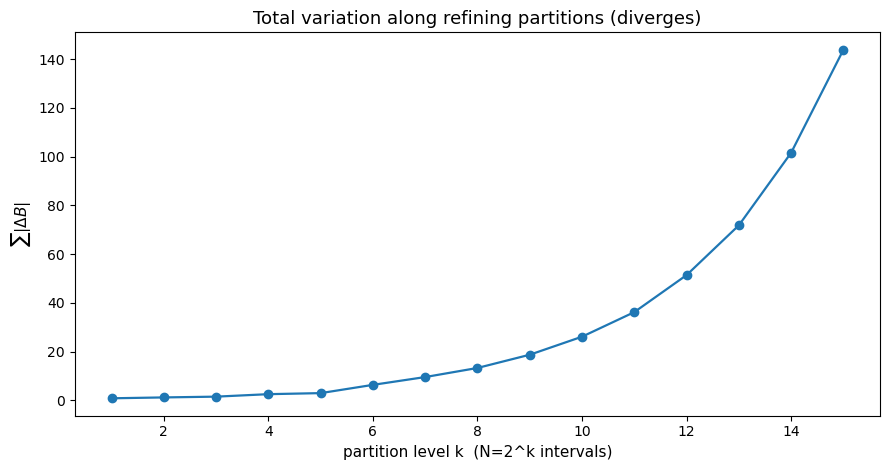

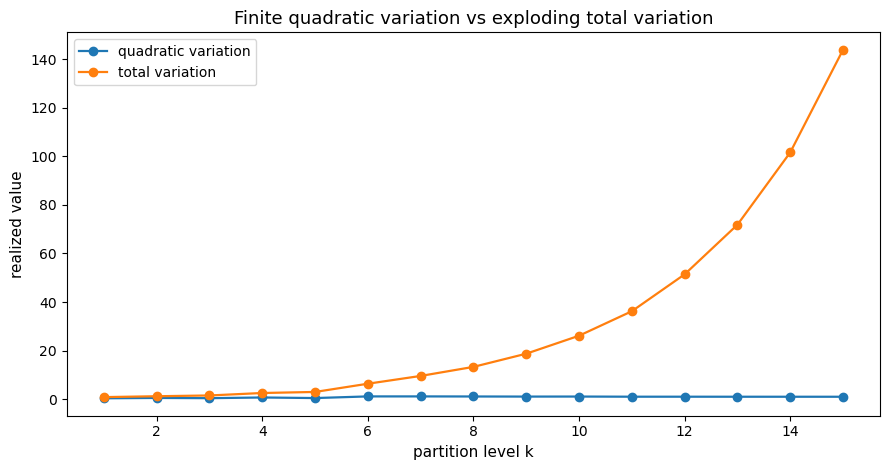

**Figure 3.** Same path, same partitions, opposite behavior: total variation blows up, quadratic variation settles down.

In [4]:
TV = np.array([realized_tv_from_fine_increments(dB, k) for k in levels])

plt.figure()
plt.plot(levels, TV, marker="o", linewidth=1.6)
plt.title("Total variation along refining partitions (diverges)")
plt.xlabel("partition level k  (N=2^k intervals)")
plt.ylabel(r"$\sum |\Delta B|$")
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(levels, QV, marker="o", linewidth=1.6, label="quadratic variation")
plt.plot(levels, TV, marker="o", linewidth=1.6, label="total variation")
plt.title("Finite quadratic variation vs exploding total variation")
plt.xlabel("partition level k")
plt.ylabel("realized value")
plt.legend()
plt.tight_layout()
plt.show()
show_caption("Same path, same partitions, opposite behavior: total variation blows up, quadratic variation settles down.")


## 10. Visual experiment C — adding smooth drift does not change quadratic variation

Let
\[
X_t = B_t + a \sin(2\pi t).
\]

The added sinusoid has finite variation, so it should not change the quadratic variation in the limit.
That is the first serious structural fact beyond plain Brownian motion.


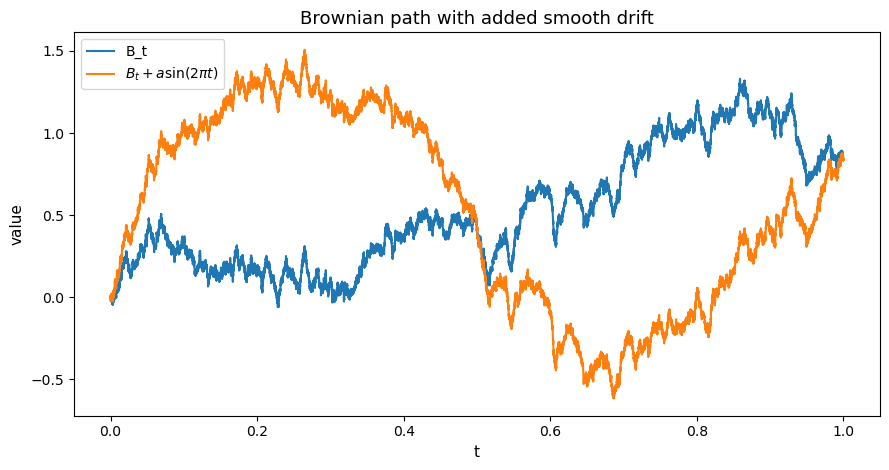

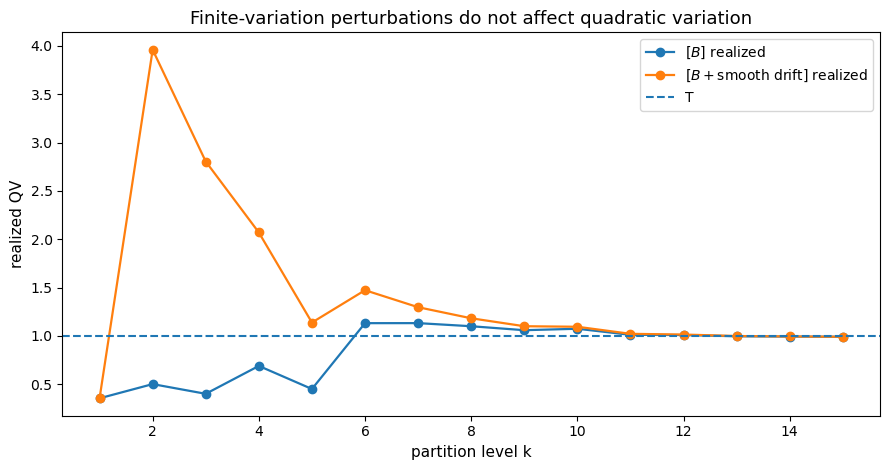

**Figure 4.** Quadratic variation ignores the smooth drift. It only feels the rough martingale part.

In [5]:
a = 1.2
drift = a * np.sin(2*np.pi*t)
X = B + drift
dX = np.diff(X)

QV_B = np.array([realized_qv_from_fine_increments(dB, k) for k in levels])
QV_X = np.array([realized_qv_from_fine_increments(dX, k) for k in levels])

plt.figure()
plt.plot(t, B, linewidth=1.5, label="B_t")
plt.plot(t, X, linewidth=1.5, label=r"$B_t + a\sin(2\pi t)$")
plt.title("Brownian path with added smooth drift")
plt.xlabel("t")
plt.ylabel("value")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(levels, QV_B, marker="o", linewidth=1.6, label=r"$[B]$ realized")
plt.plot(levels, QV_X, marker="o", linewidth=1.6, label=r"$[B + \text{smooth drift}]$ realized")
plt.axhline(T, linestyle="--", label="T")
plt.title("Finite-variation perturbations do not affect quadratic variation")
plt.xlabel("partition level k")
plt.ylabel("realized QV")
plt.legend()
plt.tight_layout()
plt.show()
show_caption("Quadratic variation ignores the smooth drift. It only feels the rough martingale part.")


## 11. Visual experiment D — stochastic volatility changes the clock

Now simulate
\[
X_t = \int_0^t \sigma(s)\,dB_s
\]
with deterministic but time-varying volatility
\[
\sigma(s)=0.5 + 0.9\big(0.5+\sin^2(3\pi s)\big).
\]

Then
\[
[X]_t = \int_0^t \sigma(s)^2\,ds,
\]
not simply \(t\).

So quadratic variation becomes the process’s **own clock speed**.


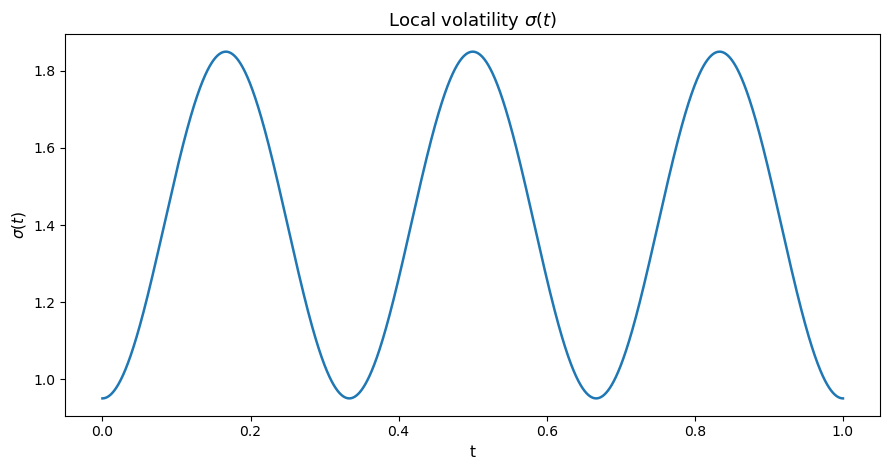

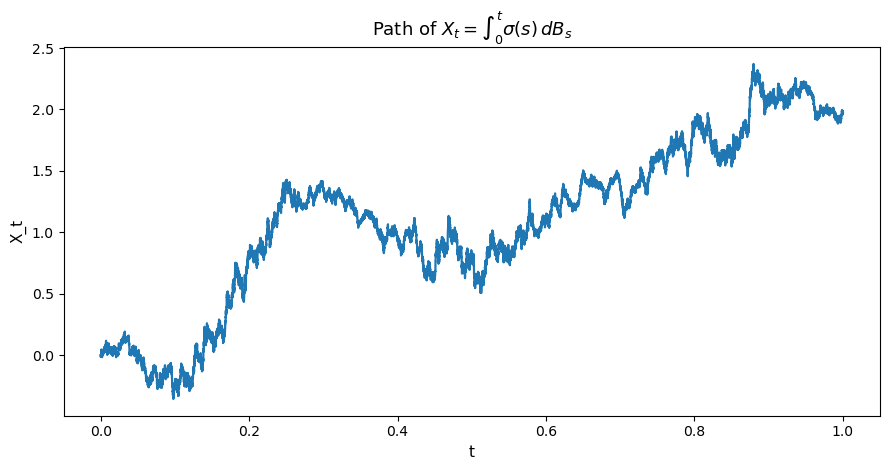

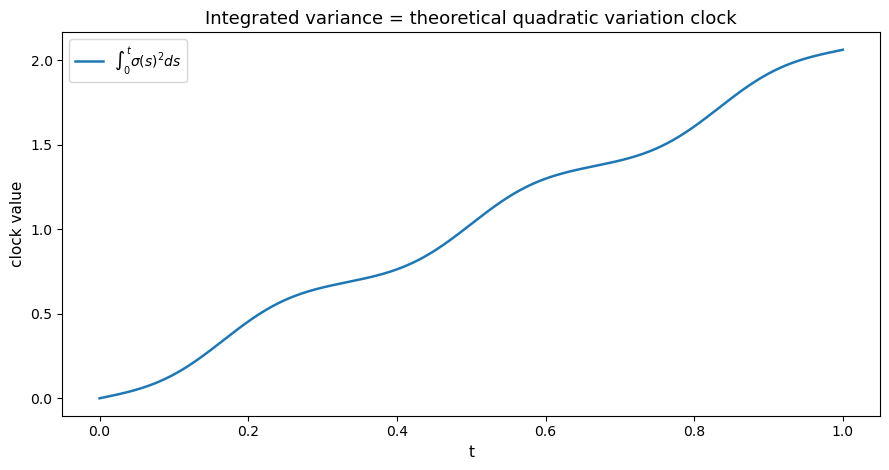

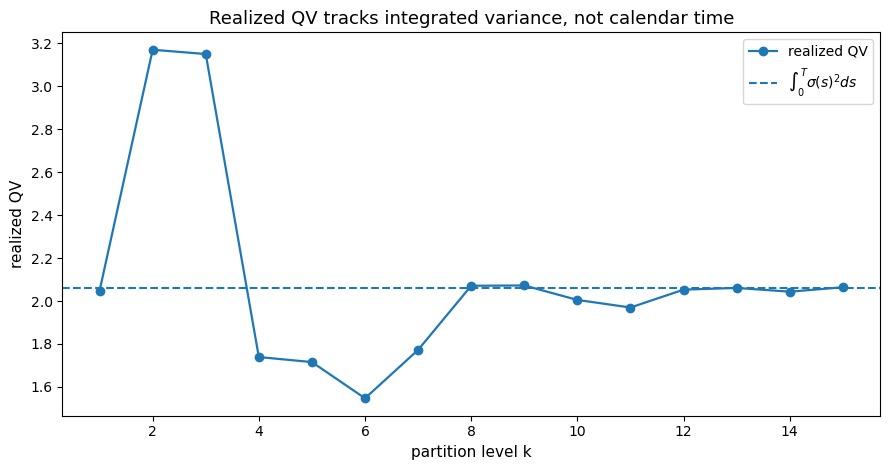

**Figure 5.** Volatility does not just change the scale of fluctuations — it changes the rate at which quadratic variation accumulates.

In [6]:
T = 1.0
J = 15
N = 2**J
t = np.linspace(0.0, T, N+1)
dt = T / N
mid = t[:-1]

sigma = 0.5 + 0.9*(0.5 + np.sin(3*np.pi*mid)**2)
dB_sv = np.sqrt(dt) * rng.standard_normal(N)
dX_sv = sigma * dB_sv
X_sv = np.concatenate([[0.0], np.cumsum(dX_sv)])

A = np.concatenate([[0.0], np.cumsum(sigma**2 * dt)])   # integrated variance / theoretical bracket
QV_sv = np.array([realized_qv_from_fine_increments(dX_sv, k) for k in np.arange(1, J+1)])

plt.figure()
plt.plot(t[:-1], sigma, linewidth=1.8)
plt.title(r"Local volatility $\sigma(t)$")
plt.xlabel("t")
plt.ylabel(r"$\sigma(t)$")
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(t, X_sv, linewidth=1.6)
plt.title(r"Path of $X_t = \int_0^t \sigma(s)\,dB_s$")
plt.xlabel("t")
plt.ylabel("X_t")
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(t, A, linewidth=1.8, label=r"$\int_0^t \sigma(s)^2 ds$")
plt.title("Integrated variance = theoretical quadratic variation clock")
plt.xlabel("t")
plt.ylabel("clock value")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(np.arange(1, J+1), QV_sv, marker="o", linewidth=1.6, label="realized QV")
plt.axhline(A[-1], linestyle="--", label=r"$\int_0^T \sigma(s)^2 ds$")
plt.title("Realized QV tracks integrated variance, not calendar time")
plt.xlabel("partition level k")
plt.ylabel("realized QV")
plt.legend()
plt.tight_layout()
plt.show()
show_caption("Volatility does not just change the scale of fluctuations — it changes the rate at which quadratic variation accumulates.")


## 12. Visual experiment E — covariation for correlated Brownian motions

Let
\[
dB_t^{(2)} = \rho\, dB_t^{(1)} + \sqrt{1-\rho^2}\, dW_t.
\]

Then realized covariation should converge to \(\rho T\).


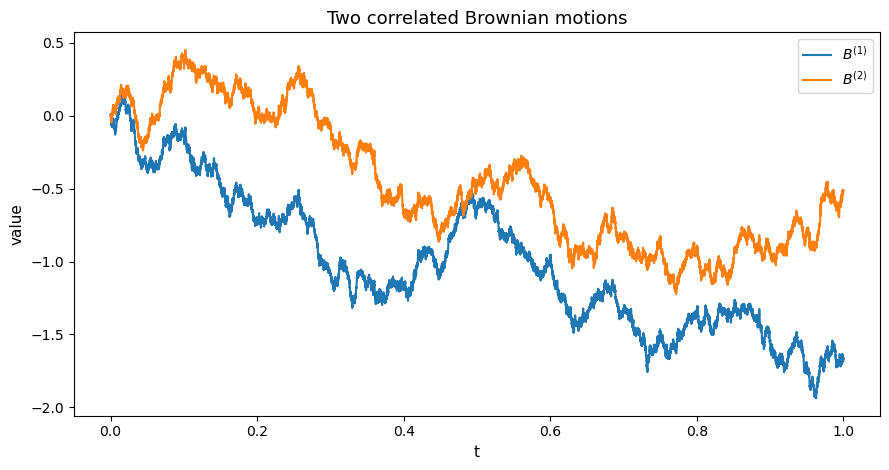

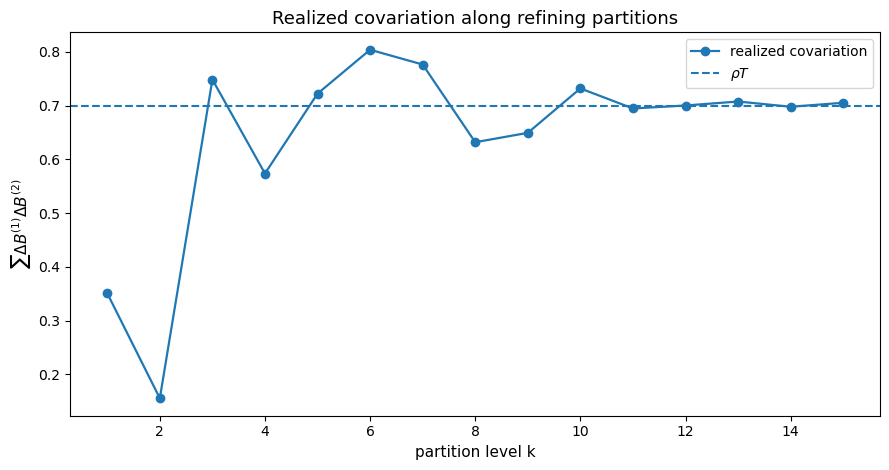

**Figure 6.** Covariation is the pathwise cumulative covariance. The limit is not decorational bookkeeping — it is the bilinear term in Itô calculus.

In [7]:
T = 1.0
J = 15
rho = 0.7

t, B1, dB1, dt = simulate_brownian_path(T=T, J=J, rng=rng)
dW = np.sqrt(dt) * rng.standard_normal(len(dB1))
dB2 = rho*dB1 + np.sqrt(1-rho**2)*dW
B2 = np.concatenate([[0.0], np.cumsum(dB2)])

COV = np.array([realized_cov_from_fine_increments(dB1, dB2, k) for k in levels])

plt.figure()
plt.plot(t, B1, linewidth=1.5, label=r"$B^{(1)}$")
plt.plot(t, B2, linewidth=1.5, label=r"$B^{(2)}$")
plt.title("Two correlated Brownian motions")
plt.xlabel("t")
plt.ylabel("value")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(levels, COV, marker="o", linewidth=1.6, label="realized covariation")
plt.axhline(rho*T, linestyle="--", label=r"$\rho T$")
plt.title("Realized covariation along refining partitions")
plt.xlabel("partition level k")
plt.ylabel(r"$\sum \Delta B^{(1)}\Delta B^{(2)}$")
plt.legend()
plt.tight_layout()
plt.show()
show_caption("Covariation is the pathwise cumulative covariance. The limit is not decorational bookkeeping — it is the bilinear term in Itô calculus.")


## 13. Visual experiment F — \(M_t^2-[M]_t\) behaves like a martingale

We now test the compensated-square identity numerically on many paths.

Take
\[
M_t=\int_0^t \sigma(s)\,dB_s,\qquad [M]_t=\int_0^t \sigma(s)^2\,ds.
\]

Then \(E[M_t^2-[M]_t]\) should stay near zero.


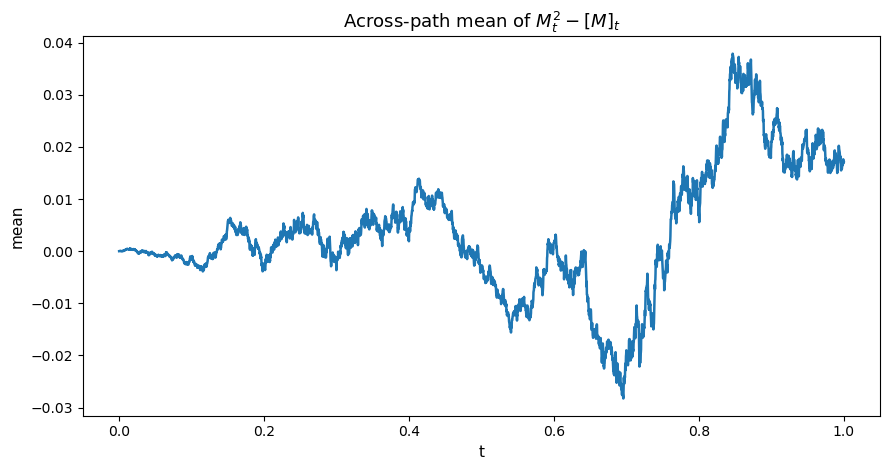

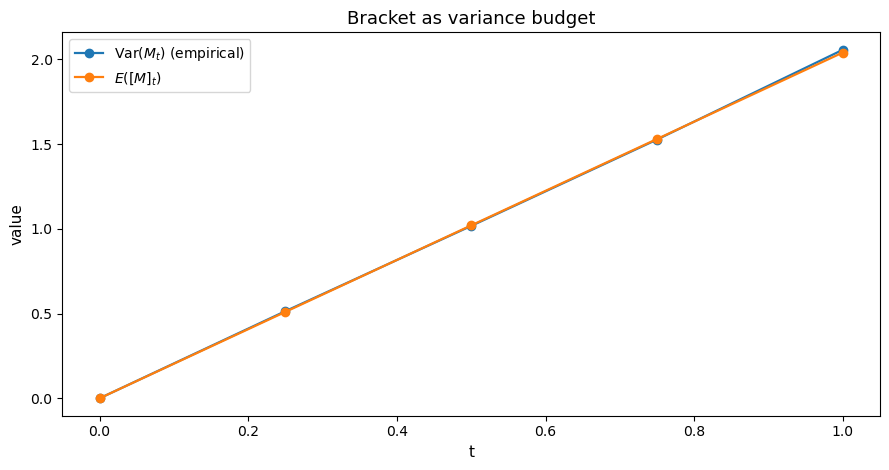

**Figure 7.** The bracket is the predictable growth needed to compensate the square. That is why it acts like an internal variance clock.

In [8]:
def simulate_sigma_martingale_paths(n_paths=4000, T=1.0, J=12, seed=123):
    rng_local = np.random.default_rng(seed)
    N = 2**J
    t = np.linspace(0.0, T, N+1)
    dt = T / N
    mid = t[:-1]
    sigma = 0.6 + 0.8*(0.5 + np.sin(2*np.pi*mid)**2)
    dB = np.sqrt(dt) * rng_local.standard_normal((n_paths, N))
    dM = sigma[None, :] * dB
    M = np.concatenate([np.zeros((n_paths,1)), np.cumsum(dM, axis=1)], axis=1)
    bracket_path = np.cumsum((sigma**2)[None,:] * dt, axis=1)
    bracket = np.concatenate([np.zeros((n_paths,1)), np.repeat(bracket_path, n_paths, axis=0)], axis=1)
    return t, M, bracket

t_mc, M_mc, A_mc = simulate_sigma_martingale_paths(n_paths=5000, T=1.0, J=12, seed=321)
comp = M_mc**2 - A_mc

plt.figure()
plt.plot(t_mc, comp.mean(axis=0), linewidth=1.8)
plt.title(r"Across-path mean of $M_t^2-[M]_t$")
plt.xlabel("t")
plt.ylabel("mean")
plt.tight_layout()
plt.show()

times_idx = np.linspace(0, len(t_mc)-1, 5, dtype=int)
vars_M = M_mc[:, times_idx].var(axis=0)
mean_br = A_mc[:, times_idx].mean(axis=0)

plt.figure()
plt.plot(t_mc[times_idx], vars_M, marker="o", linewidth=1.6, label=r"$\mathrm{Var}(M_t)$ (empirical)")
plt.plot(t_mc[times_idx], mean_br, marker="o", linewidth=1.6, label=r"$E([M]_t)$")
plt.title("Bracket as variance budget")
plt.xlabel("t")
plt.ylabel("value")
plt.legend()
plt.tight_layout()
plt.show()
show_caption("The bracket is the predictable growth needed to compensate the square. That is why it acts like an internal variance clock.")


## 14. Visual experiment G — a DDS-style clock picture

For deterministic \(\sigma\), the martingale
\[
M_t=\int_0^t \sigma(s)\,dB_s
\]
has the same law as Brownian motion evaluated at time
\[
A_t=\int_0^t \sigma(s)^2 ds.
\]

This is not yet the full DDS theorem, but it is the cleanest picture of the idea:
calendar time \(t\) is not the natural clock — quadratic variation is.


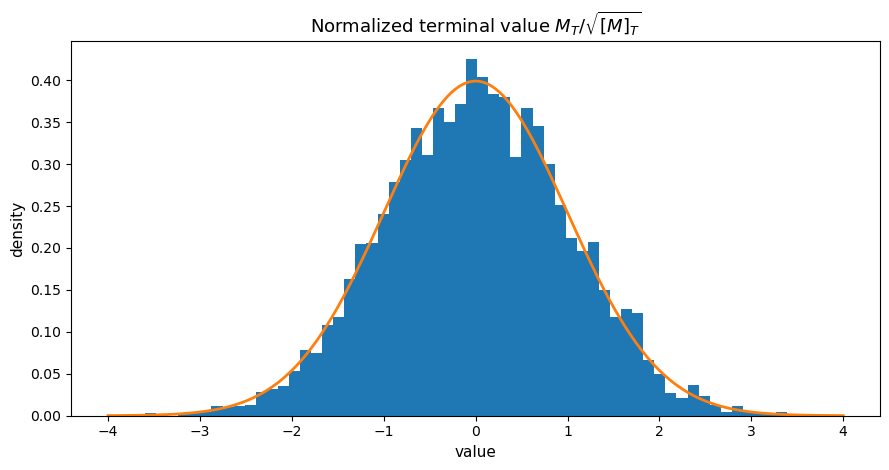

**Figure 8.** After rescaling by the quadratic-variation clock, the terminal law becomes standard normal. That is the clock interpretation in one picture.

In [9]:
# Compare the law of M_T with N(0, A_T) via normalization
MT = M_mc[:, -1]
AT = A_mc[0, -1]

plt.figure()
plt.hist(MT / np.sqrt(AT), bins=60, density=True)
x = np.linspace(-4, 4, 400)
phi = (1/np.sqrt(2*np.pi)) * np.exp(-0.5*x**2)
plt.plot(x, phi, linewidth=2.0)
plt.title(r"Normalized terminal value $M_T / \sqrt{[M]_T}$")
plt.xlabel("value")
plt.ylabel("density")
plt.tight_layout()
plt.show()
show_caption("After rescaling by the quadratic-variation clock, the terminal law becomes standard normal. That is the clock interpretation in one picture.")


## 15. Takeaways

1. **Quadratic variation is not a technicality.** It is the surviving second-order geometry of rough paths.  
2. **Brownian motion is rough enough to destroy total variation, but structured enough to retain quadratic variation.**  
3. **Drift does not contribute to quadratic variation.** For Itô processes, QV measures accumulated local variance.  
4. **Covariation is the bilinear second-order object** that drives product rules and multidimensional Itô calculus.  
5. **For continuous martingales, \([M]\) is the variance clock.** That is why \(M^2-[M]\) is martingale-like, why Lévy’s characterization works, and why DDS turns martingales into time-changed Brownian motions.

### Suggested next chapter
The Itô integral as a process:
\[
M_t = \int_0^t H_s\,dB_s,
\qquad [M]_t = \int_0^t H_s^2\,ds.
\]
That chapter is really just quadratic variation learning to speak operator language.
